# Shelter Metrics Demo

- `patch_metrics` classifies tree clusters as linear (shelterbelts) vs non-linear (patches) and outputs the number of patches in each category
- `class_metrics` calculates percentage cover in each category

In [1]:
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories
from shelterbelts.indices.shelter_metrics import patch_metrics, class_metrics
from shelterbelts.indices.shelter_metrics import linear_categories_cmap, linear_categories_labels

# Example data
buffer_file = get_filename('g2_26729_gullies_and_roads_buffer_categories.tif')

## Default Parameters

In [2]:
ds, df = patch_metrics(buffer_file)

Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outline_raster.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_widths_raster.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png


In [3]:
df.head()

,label,ellipse_length,ellipse_width,ellipse len/width,perimeter,area,orientation_degrees,skeleton_width,skeleton_length,skeleton len/width,category_id,category_name
0,1,229.371710,95.404211,2.404210,991.091450,15010.0,79.246991,80.306837,192,2.390830,12.0,Patch Core
1,4,112.645713,38.917939,2.894442,501.209199,1041.0,-2.933969,6.122523,104,16.986461,15.0,Trees in Gullies
2,8,11.852863,6.858282,1.728255,31.313708,50.0,-58.108803,6.740043,8,1.186936,15.0,Trees in Gullies
3,9,18.375348,7.203346,2.550946,48.006097,83.0,-85.585708,7.210284,13,1.802980,15.0,Trees in Gullies
4,10,8.087055,5.455497,1.482368,19.692388,29.0,-52.581955,6.573452,6,0.912762,15.0,Trees in Gullies


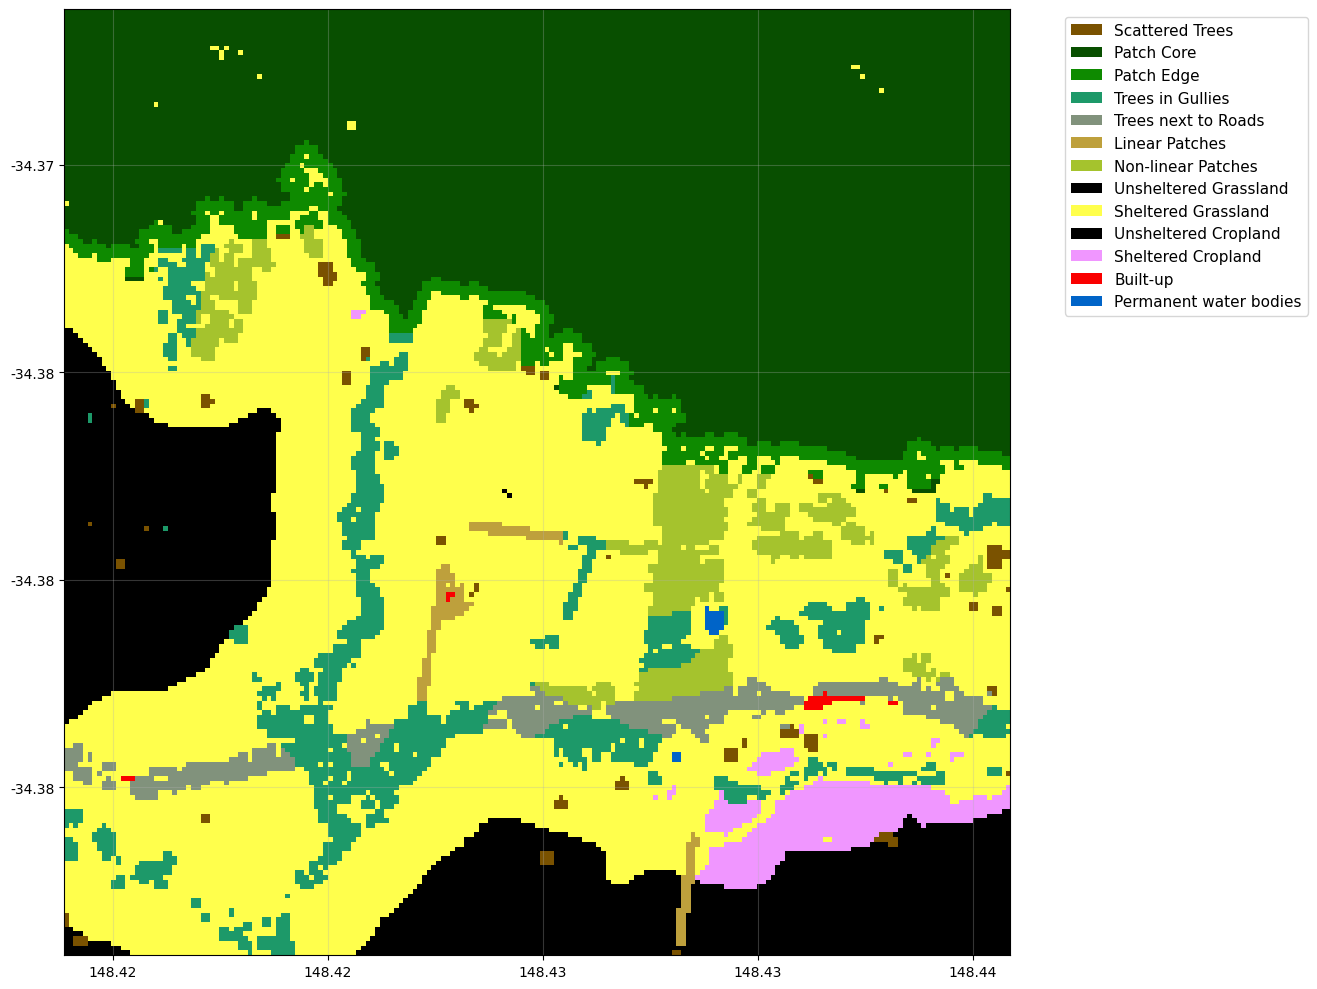

In [4]:
visualise_categories(
    ds['linear_categories'],
    colormap=linear_categories_cmap,
    labels=linear_categories_labels
)

## Changing min_shelterbelt_length and max_shelterbelt_width

Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outline_raster.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_widths_raster.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png
Saved: ./TEST_assigned_labels.tif
Saved: ./TEST_ellipse_outline_raster.tif
Saved: ./TEST_shortest_path_raster.tif
Saved: ./TEST_perpendicular_raster.tif
Saved: ./TEST_widths_raster.tif
Saved: ./TEST_patch_metrics.csv
Saved: ./TEST_linear_categories.tif
Saved: ./TEST_linear_categories.png


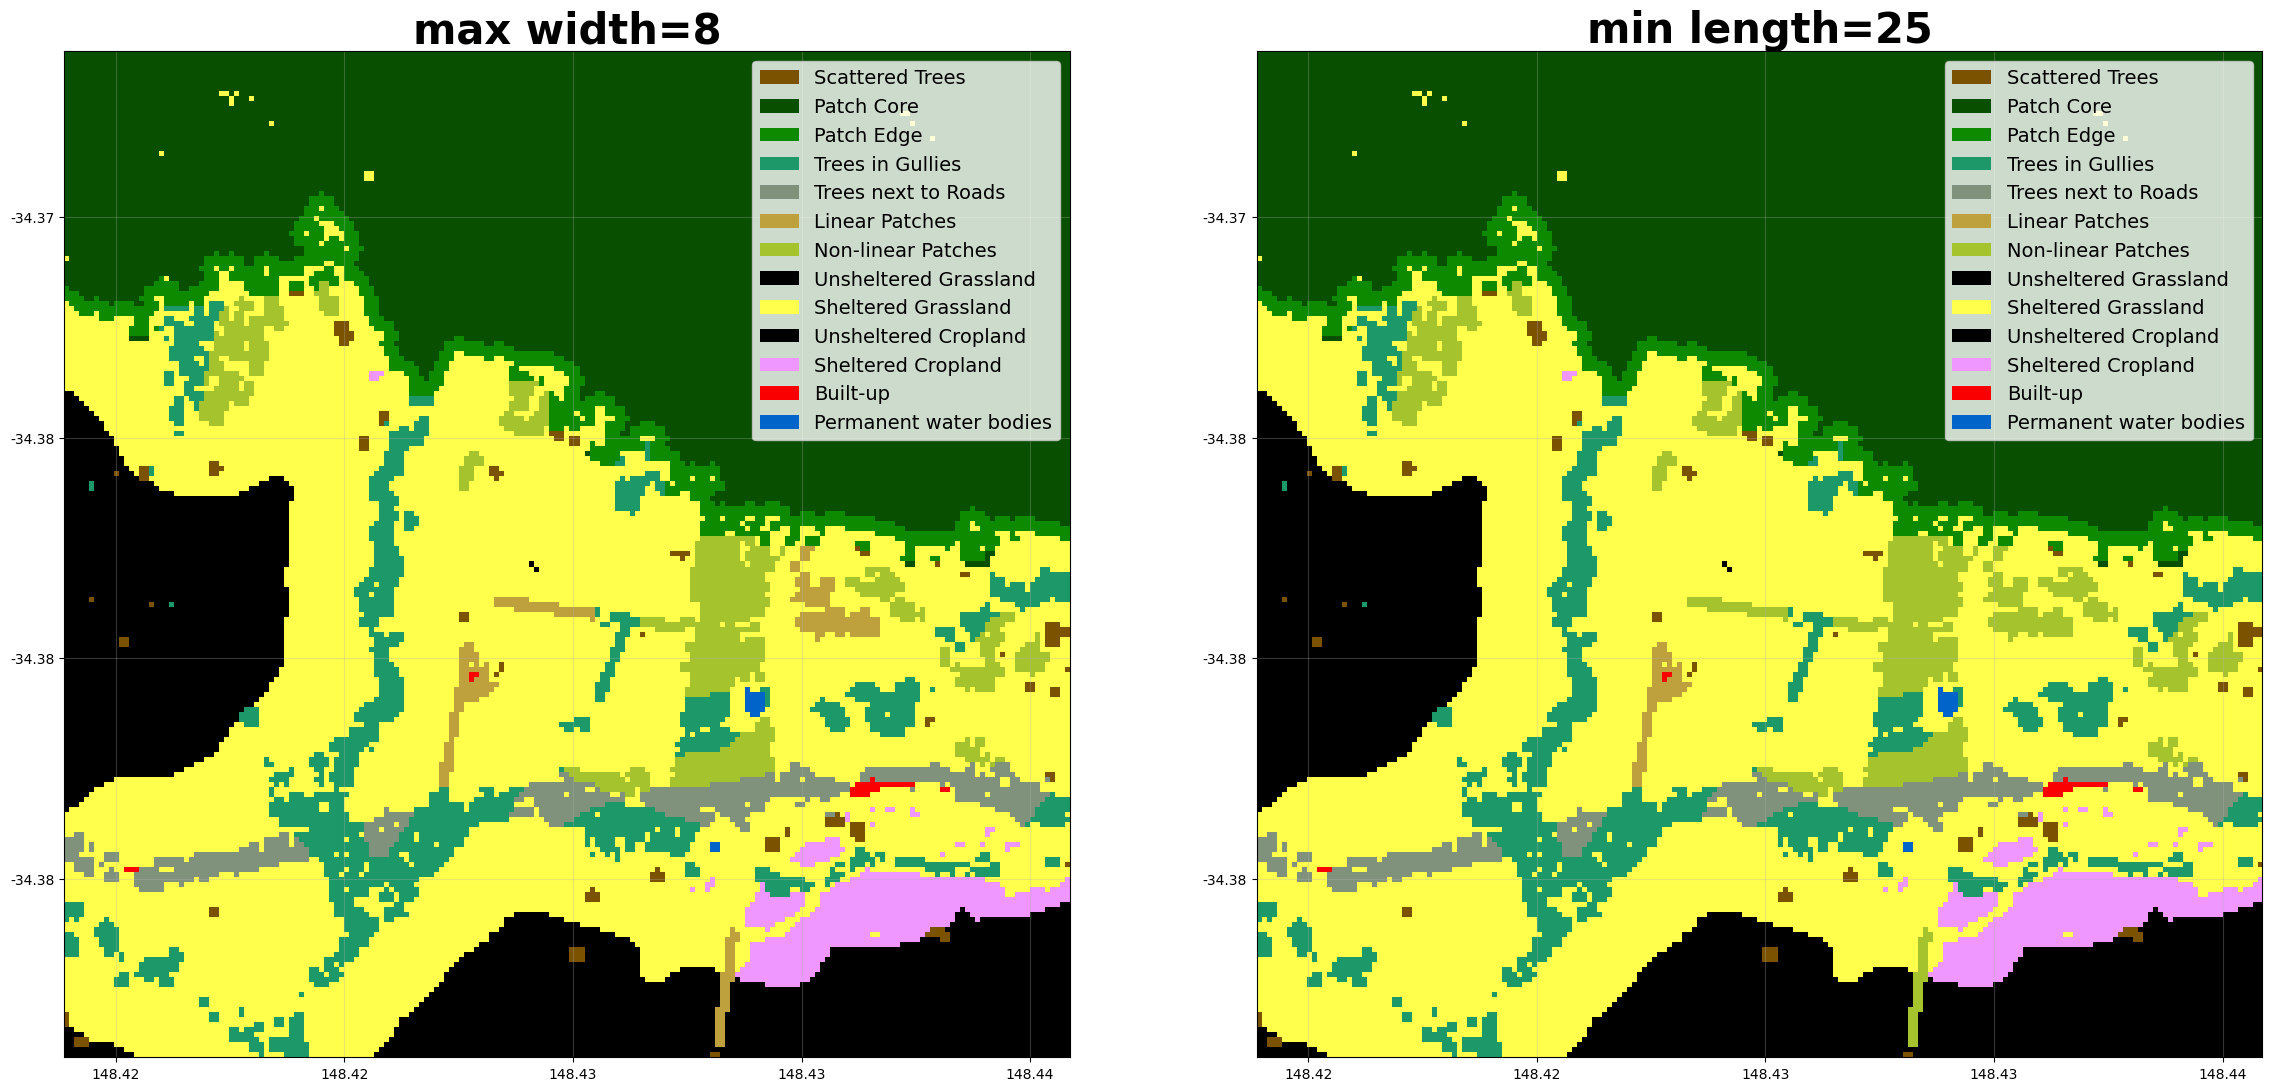

In [5]:
ds1, _ = patch_metrics(buffer_file, max_shelterbelt_width=8)
ds2, _ = patch_metrics(buffer_file, min_shelterbelt_length=25)
visualise_categories_sidebyside(
    ds1['linear_categories'], ds2['linear_categories'],
    colormap=linear_categories_cmap, labels=linear_categories_labels,
    title1="max width=8", title2="min length=25"
)

## Class Metrics

In [6]:
linear_file = get_filename('g2_26729_linear_categories.tif')
dfs = class_metrics(linear_file)

Saved: ./TEST_class_metrics.xlsx


In [7]:
dfs['Overall']

,category_id,pixel_count,percentage,landcover_group
label,,,,
Sheltered Grassland,32,14342,35.50,Grassland
Patch Core,12,13699,33.91,Trees
Unsheltered Grassland,31,4214,10.43,Grassland
Non-linear Patches,19,3032,7.50,Trees
Unsheltered Cropland,41,1273,3.15,Cropland
Patch Edge,13,1231,3.05,Trees
Linear Patches,18,791,1.96,Trees
Sheltered Cropland,42,777,1.92,Cropland
Trees in Gullies,15,660,1.63,Trees


In [8]:
dfs['Landcover']

,pixel_count,percentage
landcover_group,,
Trees,19741,48.86
Grassland,18556,45.93
Cropland,2050,5.07
Built-up,31,0.08
Water,23,0.06


In [9]:
dfs['Trees']

,pixel_count,percentage
label,,
Patch Core,13699,69.39
Non-linear Patches,3032,15.36
Patch Edge,1231,6.24
Linear Patches,791,4.01
Trees in Gullies,660,3.34
Scattered Trees,328,1.66


In [10]:
dfs['Shelter']

shelter_status,Sheltered,Unsheltered
production_category,,
Cropland,37.90,62.10
Grassland,77.29,22.71
Total,73.37,26.63


## Command Line Interface

In [11]:
!python -m shelterbelts.indices.shelter_metrics --help

usage: shelter_metrics.py [-h] [--outdir OUTDIR] [--stub STUB] [--no-plot]
                          [--no-save-csv] [--no-save-tif] [--no-save-labels]
                          [--no-save-excel]
                          [--min_shelterbelt_length MIN_SHELTERBELT_LENGTH]
                          [--max_shelterbelt_width MAX_SHELTERBELT_WIDTH]
                          [--min_patch_size MIN_PATCH_SIZE]
                          [--crop_pixels CROP_PIXELS]
                          buffer_data

positional arguments:
  buffer_data           Integer tif file generated by buffer_categories.py

options:
  -h, --help            show this help message and exit
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: TEST)
  --no-plot             Disable PNG visualisation (default: enabled)
  --no-save-csv         Disable CSV output (default: enabled)
  --no-save-tif         Di

In [12]:
!python -m shelterbelts.indices.shelter_metrics {buffer_file} --stub command_line

Saved: ./command_line_assigned_labels.tif
Saved: ./command_line_ellipse_outline_raster.tif
Saved: ./command_line_shortest_path_raster.tif
Saved: ./command_line_perpendicular_raster.tif
Saved: ./command_line_widths_raster.tif
Saved: ./command_line_patch_metrics.csv
Saved: ./command_line_linear_categories.tif
Saved: ./command_line_linear_categories.png
Saved: ./command_line_class_metrics.xlsx


In [13]:
!python -m shelterbelts.indices.shelter_metrics {buffer_file} --min_shelterbelt_length 25 --max_shelterbelt_width 8 --stub command_line

Saved: ./command_line_assigned_labels.tif
Saved: ./command_line_ellipse_outline_raster.tif
Saved: ./command_line_shortest_path_raster.tif
Saved: ./command_line_perpendicular_raster.tif
Saved: ./command_line_widths_raster.tif
Saved: ./command_line_patch_metrics.csv
Saved: ./command_line_linear_categories.tif
Saved: ./command_line_linear_categories.png
Saved: ./command_line_class_metrics.xlsx


### Cleanup
Remove the output files created by this notebook

In [14]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS
# !rm *.xlsx
# !rm *.csv

rm: cannot remove '*.xml': No such file or directory
